Shortest Path: ['A', 'B', 'E', 'D', 'G']
Total Cost: 6


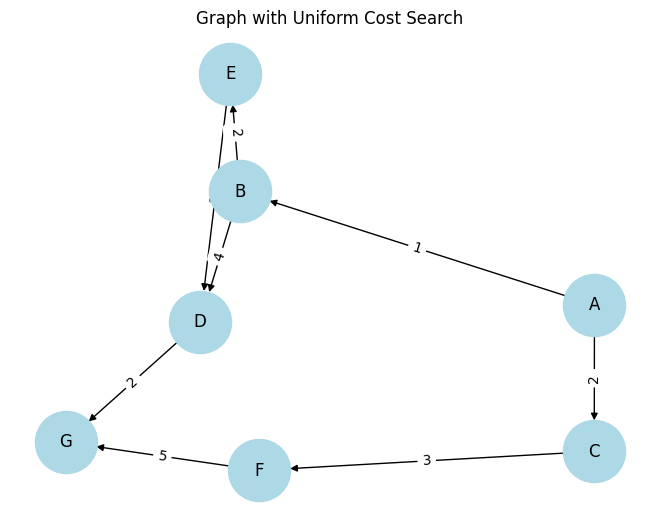

In [3]:
import networkx as nx
import matplotlib.pyplot as plt
import heapq


# ------------------ Create Graph ------------------
G = nx.DiGraph()

# Edges with weights (costs)
edges = [
    ('A', 'B', 1), ('A', 'C', 2),
    ('B', 'E', 2), ('B', 'D', 4),
    ('C', 'F', 3),
    ('E', 'D', 1),
    ('D', 'G', 2),
    ('F', 'G', 5)
]

G.add_weighted_edges_from(edges)


# ------------------ Uniform Cost Search ------------------
def ucs(graph, start, goal):
    pq = [(0, start, [])]   # (cost, current_node, path)
    visited = set()

    while pq:
        cost, node, path = heapq.heappop(pq)

        if node in visited:
            continue

        path = path + [node]
        visited.add(node)

        # Goal check
        if node == goal:
            return cost, path

        # Explore neighbors
        for neighbor in graph[node]:
            weight = graph[node][neighbor]['weight']
            heapq.heappush(pq, (cost + weight, neighbor, path))

    return float("inf"), []


# ------------------ Run UCS ------------------
cost, path = ucs(G, 'A', 'G')

print("Shortest Path:", path)
print("Total Cost:", cost)


# ------------------ Draw Graph ------------------
pos = nx.spring_layout(G)

# Edge labels (weights)
edge_labels = {(u, v): d['weight'] for u, v, d in G.edges(data=True)}

nx.draw(
    G, pos,
    with_labels=True,
    node_size=2000,
    node_color='lightblue'
)

nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Graph with Uniform Cost Search")
plt.show()

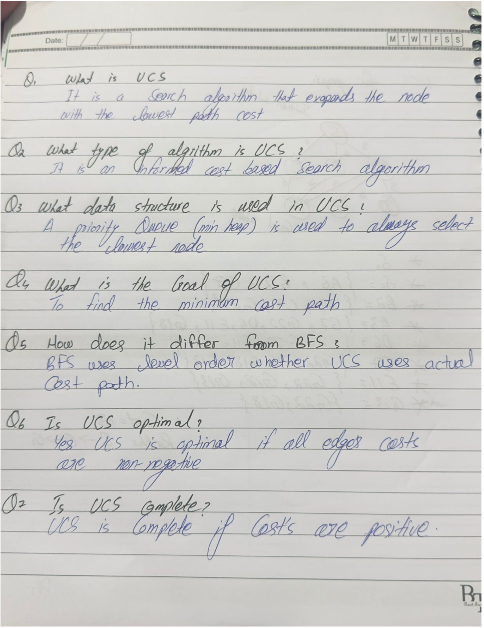

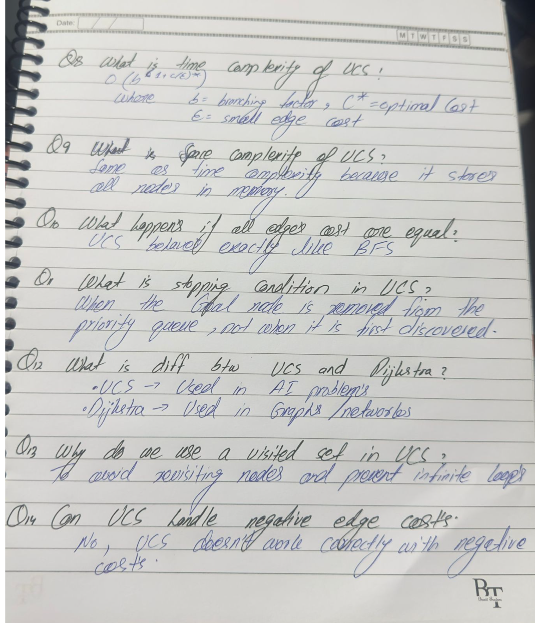